      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float6

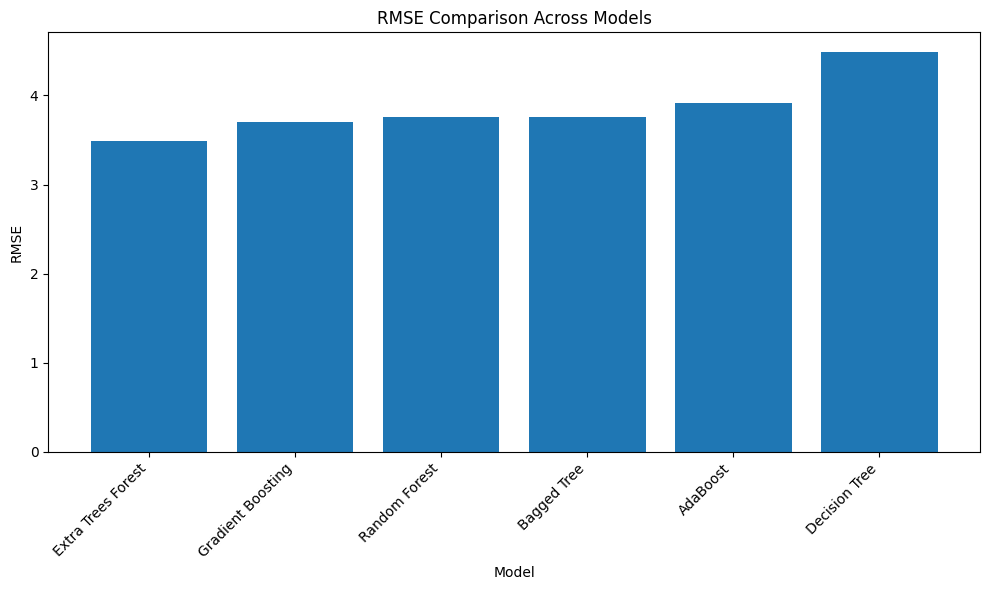

Lower RMSE and MAE values indicate better predictive performance.
Higher R squared values indicate stronger model fit.


In [1]:
# Install needed packages
!pip install pandas numpy scikit-learn matplotlib

# Import data tools
import pandas as pd
import numpy as np

# Import plotting tool
import matplotlib.pyplot as plt

# Import train/test split
from sklearn.model_selection import train_test_split

# Import model evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import tree based and ensemble models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor

# Load Boston Housing data from an online source
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

# Read the dataset into Python
housing = pd.read_csv(url)

# Display the first few rows
print(housing.head())

# Show dataset information
print(housing.info())

# Show summary statistics
print(housing.describe())

# Set predictors by removing the response variable medv
X = housing.drop("medv", axis=1)

# Set response variable
y = housing["medv"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123
)

# Create a function to evaluate each model
def evaluate_model(model_name, model):
    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions
    predictions = model.predict(X_test)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    # Calculate R squared
    r2 = r2_score(y_test, predictions)

    # Calculate MAE
    mae = mean_absolute_error(y_test, predictions)

    # Return results
    return {
        "Model": model_name,
        "RMSE": rmse,
        "R_squared": r2,
        "MAE": mae
    }

# Create models similar to the R assignment
models = [
    ("Decision Tree", DecisionTreeRegressor(random_state=123)),
    ("Bagged Tree", BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=100, random_state=123)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=123)),
    ("Extra Trees Forest", ExtraTreesRegressor(n_estimators=100, random_state=123)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=123)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, random_state=123))
]

# Store model results
results = []

# Run and evaluate each model
for name, model in models:
    results.append(evaluate_model(name, model))

# Convert results into a dataframe
results_df = pd.DataFrame(results)

# Sort models by lowest RMSE
results_df = results_df.sort_values(by="RMSE")

# Display model comparison table
print(results_df)

# Identify best model
best_model = results_df.iloc[0]

# Print best model
print("Best model based on RMSE:")
print(best_model)

# Plot RMSE comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.title("RMSE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# Final interpretation
print("Lower RMSE and MAE values indicate better predictive performance.")
print("Higher R squared values indicate stronger model fit.")